In [2]:
##import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Text(0, 0.5, 'y')

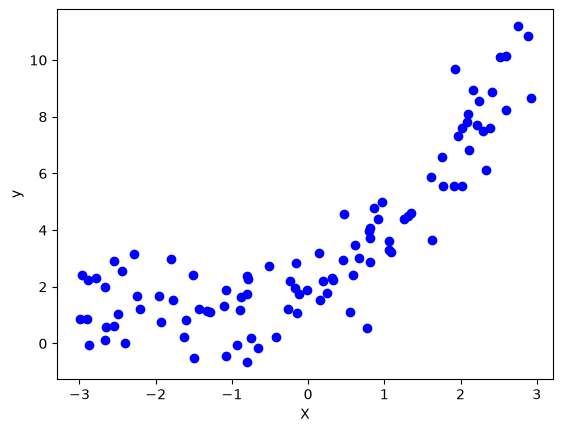

In [3]:
X= 6 * np.random.rand(100, 1) - 3
y =0.5 * X ** 2 +1.5*X+2+ np.random.randn(100, 1)
# quadratic equation used- y=0.5x^2+1.5x+2+outliers
plt.scatter(X, y, color='blue')
plt.xlabel('X')
plt.ylabel('y')

In [4]:
#train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2,random_state=42)

In [5]:
## Lets implement Simple Linear Regression
from sklearn. linear_model import LinearRegression
regression_1 = LinearRegression()
regression_1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[1.41]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[3.42]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[15.37]


In [6]:
#r2
from sklearn.metrics import r2_score
score=r2_score(y_test,regression_1.predict(X_test))
print(score)

0.7286249735363071


Text(0, 0.5, 'Y')

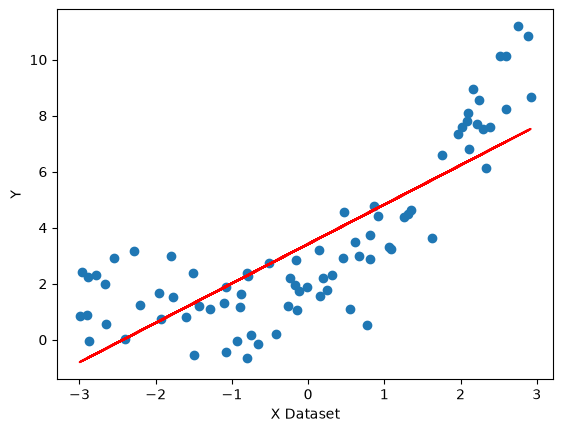

In [7]:
## Lets visualize this model
plt.plot(X_train,regression_1.predict(X_train), color='r')
plt.scatter(X_train, y_train)
plt.xlabel("X Dataset")
plt.ylabel("Y")

In [8]:
#apply poly transformation
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2,include_bias=True)
X_train_poly=poly. fit_transform(X_train)
X_test_poly=poly.transform(X_test)
X_train_poly
X_test_poly

array([[ 1.        , -2.66308621,  7.09202814],
       [ 1.        ,  2.01298811,  4.05212112],
       [ 1.        ,  1.92268594,  3.69672122],
       [ 1.        ,  1.0659731 ,  1.13629865],
       [ 1.        , -2.24359107,  5.03370089],
       [ 1.        ,  0.81063632,  0.65713124],
       [ 1.        ,  2.41752136,  5.84440952],
       [ 1.        ,  1.76694669,  3.12210061],
       [ 1.        ,  1.91924123,  3.68348692],
       [ 1.        , -0.79563885,  0.63304118],
       [ 1.        , -1.62619308,  2.64450394],
       [ 1.        , -2.54364379,  6.47012374],
       [ 1.        ,  0.32423028,  0.10512527],
       [ 1.        ,  0.58406481,  0.3411317 ],
       [ 1.        , -2.49704599,  6.23523866],
       [ 1.        , -1.32153253,  1.74644822],
       [ 1.        ,  0.80033507,  0.64053622],
       [ 1.        , -2.4380688 ,  5.94417949],
       [ 1.        ,  0.97458589,  0.94981766],
       [ 1.        ,  1.6095524 ,  2.59065893]])

In [9]:
#regression and r2 score
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score=r2_score(y_test, y_pred)
print(score)

0.8504315385163289


In [10]:
regression.coef_

array([[0.        , 1.46353441, 0.50100712]])

In [11]:
regression.intercept_

array([1.93887871])

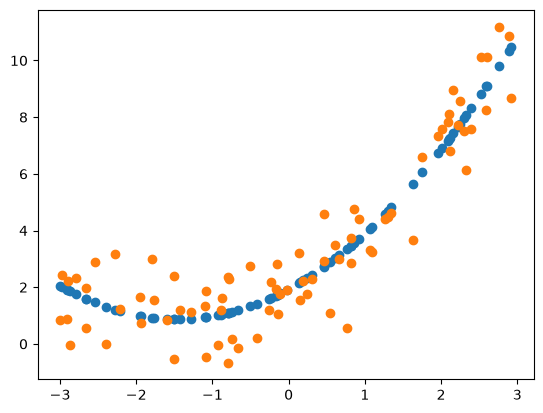

In [15]:
# vizualizing
"""
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train_poly), color='r')
plt.xlabel("X Dataset")
plt.ylabel("Y")
"""
plt.scatter(X_train, regression.predict(X_train_poly))
plt.scatter(X_train, y_train)